# Test 2 — Cross-validation, three-phase input and regularisation

This notebook improves on the Test 1 baseline (test MCC 0.438). It compares three model set-ups using **5-fold cross-validation**, so we can tell which changes genuinely help:

| Set-up | Input | Model | Purpose |
|---|---|---|---|
| **A** | Single phase (7 channels) | Test 1 model | The baseline, re-measured fairly with cross-validation |
| **B** | Three phases (21 channels) | Test 1 model | Shows the effect of three-phase input on its own |
| **C** | Three phases (21 channels) | Smaller, regularised model with a learning-rate schedule | Shows the extra effect of reducing overfitting |

Comparing A with B isolates the three-phase change, and B with C isolates the regularisation changes. This "one change at a time" comparison (an **ablation study**) is good evidence for the report.

**The test set is not used here.** All comparisons use cross-validation on the training and validation data. The final test evaluation (section 11) is switched off until the final model is chosen.

**Before running:** attach the `final-year-project` notebook as input, and switch on the GPU (**Settings > Accelerator**). This notebook trains 15 models (3 set-ups × 5 folds), which takes much longer on CPU.

## 1. Imports and settings

In [1]:
import glob, json, os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import matthews_corrcoef, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
N_FOLDS = 5
BATCH_SIZE = 64
MAX_EPOCHS = 60
PATIENCE = 10              # early stopping: epochs without improvement in validation MCC
OUT_DIR = '/kaggle/working'
os.makedirs(f'{OUT_DIR}/models', exist_ok=True)

CONFIGS = {
    'A_single_phase':     dict(three_phase=False, model='baseline', lr=1e-3, weight_decay=1e-4, scheduler=False),
    'B_three_phase':      dict(three_phase=True,  model='baseline', lr=1e-3, weight_decay=1e-4, scheduler=False),
    'C_three_phase_reg':  dict(three_phase=True,  model='small',    lr=1e-3, weight_decay=1e-3, scheduler=True),
}
RUN_CONFIGS = list(CONFIGS)          # to run fewer, e.g. ['C_three_phase_reg']

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('PyTorch', torch.__version__)

Using device: cuda
PyTorch 2.11.0+cu128


## 2. Load the prepared data

We load the **un-normalised** features this time. In cross-validation, each fold calculates its own normalisation statistics from its own training part, so no information from a fold's validation part leaks into training.

In [2]:
matches = glob.glob('/kaggle/input/**/X_processed.npy', recursive=True)
assert matches, 'X_processed.npy not found: attach the final-year-project notebook as input'
PREP_DIR = matches[0].rsplit('/', 1)[0]
print('Loading from', PREP_DIR)

X = np.load(f'{PREP_DIR}/X_processed.npy')          # (8712, 160, 7)
meta = pd.read_csv(f'{PREP_DIR}/meta_with_split.csv')
y = meta['target'].values
groups = meta['id_measurement'].values
print('X:', X.shape, '| PD signals:', y.sum())

Loading from /kaggle/input/notebooks/ronakrobert/final-year-project
X: (8712, 160, 7) | PD signals: 525


## 3. Build the three-phase input

In Test 1, each signal was judged on its own. Here, each signal is given its own 7 features **plus** the 7 features of the other two phases of the same measurement, making 21 channels. The signal's own phase always comes first, then the next phase, then the one after, so the model always knows which phase it is judging.

We still predict one label **per signal**, exactly as in Test 1, so the results stay directly comparable. PD often shows up across phases, and comparing phases can also help separate real PD from noise that affects all three phases equally.

In [3]:
pos = {(m, p): i for i, (m, p) in enumerate(zip(meta['id_measurement'], meta['phase']))}
assert all((m, q) in pos for m in meta['id_measurement'].unique() for q in range(3)), 'a measurement is missing a phase'

order = np.array([[pos[(m, (p + k) % 3)] for k in range(3)]
                  for m, p in zip(meta['id_measurement'], meta['phase'])])   # own phase, next, next-next
X3 = np.concatenate([X[order[:, k]] for k in range(3)], axis=2)            # (8712, 160, 21)
print('Three-phase input:', X3.shape)

Three-phase input: (8712, 160, 21)


## 4. Cross-validation folds

The original training and validation sets are combined into one **pool** (7,404 signals). The test set (1,308 signals) stays untouched.

`StratifiedGroupKFold` divides the pool into 5 folds. **Grouped** means all phases of a measurement stay in the same fold (no leakage, as before). **Stratified** means each fold has a similar share of PD signals. Each fold takes one turn as the validation set while the other four train the model, so every pool signal gets exactly one prediction from a model that never trained on it. These are called **out-of-fold (OOF) predictions**.

In [4]:
pool_idx = np.where(meta['split'].isin(['train', 'val']))[0]
test_idx = np.where(meta['split'] == 'test')[0]

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = [(pool_idx[tr], pool_idx[va]) for tr, va in sgkf.split(pool_idx, y[pool_idx], groups[pool_idx])]

for k, (tr, va) in enumerate(folds, 1):
    assert not set(groups[tr]) & set(groups[va]), 'a measurement appears in both parts of a fold'
    print(f'Fold {k}: train {len(tr)} ({y[tr].sum()} PD) | validation {len(va)} ({y[va].sum()} PD)')
print(f'Pool: {len(pool_idx)} signals | Test (held out): {len(test_idx)} signals')

Fold 1: train 5925 (336 PD) | validation 1479 (116 PD)
Fold 2: train 5922 (358 PD) | validation 1482 (94 PD)
Fold 3: train 5922 (372 PD) | validation 1482 (80 PD)
Fold 4: train 5922 (361 PD) | validation 1482 (91 PD)
Fold 5: train 5925 (381 PD) | validation 1479 (71 PD)
Pool: 7404 signals | Test (held out): 1308 signals


## 5. The models

**Baseline model** (`PDNet`): the Test 1 architecture, now accepting either 7 or 21 input channels.

**Smaller, regularised model** (`PDNetSmall`), designed to reduce the overfitting seen in Test 1, where 82% of the parameters sat in one fully connected layer:
- The third block keeps 64 filters instead of 128.
- A **1×1 convolution** shrinks 64 channels to 16 before flattening, so the classifier receives 320 numbers instead of 2,560. Flattening still keeps the position (phase) information.
- The hidden layer has 32 units instead of 64, and dropout rises from 0.3 to 0.5.

Set-up C also uses stronger weight decay (1e-3) and a **learning-rate schedule**: if validation MCC stops improving for 4 epochs, the learning rate halves, allowing finer adjustments.

In [5]:
def conv_block(c_in, c_out, k):
    return nn.Sequential(nn.Conv1d(c_in, c_out, k, padding=k // 2), nn.BatchNorm1d(c_out), nn.ReLU(), nn.MaxPool1d(2))

class PDNet(nn.Module):                        # Test 1 architecture
    def __init__(self, in_channels, seq_len=160):
        super().__init__()
        self.features = nn.Sequential(conv_block(in_channels, 32, 5), conv_block(32, 64, 5), conv_block(64, 128, 3))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128 * (seq_len // 8), 64),
                                        nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

class PDNetSmall(nn.Module):                   # smaller, regularised version
    def __init__(self, in_channels, seq_len=160):
        super().__init__()
        self.features = nn.Sequential(conv_block(in_channels, 32, 5), conv_block(32, 64, 5), conv_block(64, 64, 3),
                                      nn.Conv1d(64, 16, 1), nn.BatchNorm1d(16), nn.ReLU())
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), nn.Linear(16 * (seq_len // 8), 32),
                                        nn.ReLU(), nn.Dropout(0.5), nn.Linear(32, 1))
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

def build_model(cfg):
    in_ch = 21 if cfg['three_phase'] else 7
    return (PDNet if cfg['model'] == 'baseline' else PDNetSmall)(in_ch)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

for name, cfg in CONFIGS.items():
    print(f'{name}: {count_params(build_model(cfg)):,} trainable parameters')

A_single_phase: 200,577 trainable parameters
B_three_phase: 202,817 trainable parameters
C_three_phase_reg: 37,745 trainable parameters


## 6. Training functions

The same steps as Test 1, wrapped into functions so they can run once per fold:
- `normalise` calculates the mean and standard deviation on the fold's **training part only** and applies them to both parts.
- `train_fold` trains one model with class weighting, early stopping on validation MCC, and (for set-up C) the learning-rate schedule. It returns the best model and its validation predictions.

In [6]:
class PDDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)   # (N, channels, 160)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def normalise(X_train, X_other):
    mean = X_train.mean(axis=(0, 1)); std = X_train.std(axis=(0, 1)) + 1e-6
    return (X_train - mean) / std, (X_other - mean) / std, mean, std

def predict(model, loader):
    model.eval(); probs = []
    with torch.no_grad():
        for xb, _ in loader:
            probs.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
    return np.concatenate(probs)

def train_fold(cfg, X_tr, y_tr, X_va, y_va):
    set_seed(SEED)
    model = build_model(cfg).to(device)
    pos_weight = torch.tensor([(len(y_tr) - y_tr.sum()) / y_tr.sum()], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = (torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)
                 if cfg['scheduler'] else None)
    train_loader = DataLoader(PDDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(PDDataset(X_va, y_va), batch_size=256)

    history, best_mcc, best_state, best_epoch, waited = [], -1.0, None, 0, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        val_mcc = matthews_corrcoef(y_va, predict(model, val_loader) > 0.5)
        history.append(val_mcc)
        if scheduler:
            scheduler.step(val_mcc)
        if val_mcc > best_mcc:
            best_mcc, best_epoch, waited = val_mcc, epoch, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            waited += 1
            if waited >= PATIENCE:
                break
    model.load_state_dict(best_state)
    return model, predict(model, val_loader), history, best_epoch

## 7. Run the cross-validation

For each set-up and each fold: normalise, train, and store the out-of-fold predictions, the trained model and its normalisation statistics. A progress line prints after each fold. Expect this cell to take a while: roughly a few minutes per fold on GPU, and considerably longer on CPU.

In [7]:
results = {}
for name in RUN_CONFIGS:
    cfg = CONFIGS[name]
    X_in = X3 if cfg['three_phase'] else X
    oof = np.zeros(len(meta)); fold_of = np.full(len(meta), -1)
    histories, best_epochs, fold_stats = [], [], []
    t0 = time.time()
    for k, (tr, va) in enumerate(folds, 1):
        X_tr, X_va, mean, std = normalise(X_in[tr], X_in[va])
        model, va_probs, hist, best_epoch = train_fold(cfg, X_tr, y[tr], X_va, y[va])
        oof[va] = va_probs; fold_of[va] = k
        histories.append(hist); best_epochs.append(best_epoch)
        torch.save(model.state_dict(), f'{OUT_DIR}/models/{name}_fold{k}.pt')
        fold_stats.append((mean, std))
        print(f'{name} | fold {k}: best epoch {best_epoch}, fold MCC@0.5 {max(hist):.3f}, '
              f'{time.time() - t0:.0f}s elapsed')
    results[name] = dict(oof=oof, fold_of=fold_of, histories=histories, best_epochs=best_epochs,
                         fold_stats=fold_stats, minutes=(time.time() - t0) / 60)
    print(f'{name} finished in {results[name]["minutes"]:.1f} min\n')

A_single_phase | fold 1: best epoch 4, fold MCC@0.5 0.622, 13s elapsed
A_single_phase | fold 2: best epoch 10, fold MCC@0.5 0.599, 21s elapsed
A_single_phase | fold 3: best epoch 23, fold MCC@0.5 0.630, 34s elapsed
A_single_phase | fold 4: best epoch 2, fold MCC@0.5 0.549, 39s elapsed
A_single_phase | fold 5: best epoch 17, fold MCC@0.5 0.545, 50s elapsed
A_single_phase finished in 0.8 min

B_three_phase | fold 1: best epoch 2, fold MCC@0.5 0.633, 6s elapsed
B_three_phase | fold 2: best epoch 28, fold MCC@0.5 0.670, 23s elapsed
B_three_phase | fold 3: best epoch 23, fold MCC@0.5 0.715, 37s elapsed
B_three_phase | fold 4: best epoch 11, fold MCC@0.5 0.591, 47s elapsed
B_three_phase | fold 5: best epoch 6, fold MCC@0.5 0.569, 55s elapsed
B_three_phase finished in 0.9 min

C_three_phase_reg | fold 1: best epoch 15, fold MCC@0.5 0.658, 12s elapsed
C_three_phase_reg | fold 2: best epoch 49, fold MCC@0.5 0.752, 40s elapsed
C_three_phase_reg | fold 3: best epoch 2, fold MCC@0.5 0.719, 46s ela

## 8. Compare the set-ups

For each set-up we choose **one cut-off** from the out-of-fold predictions (the one with the highest overall MCC), then report:
- **OOF MCC**: MCC over all 7,404 pool signals at that cut-off. This is the main comparison number.
- **Fold MCC mean ± SD**: MCC of each fold separately, at the same cut-off. The standard deviation shows how much results vary between folds. A difference between set-ups that is much smaller than this spread may just be chance.
- Recall, precision and false alarms, calculated over all OOF predictions.

In [8]:
def summarise(name):
    r = results[name]; p = r['oof'][pool_idx]; t = y[pool_idx]; f = r['fold_of'][pool_idx]
    thresholds = np.arange(0.05, 0.96, 0.01)
    mccs = [matthews_corrcoef(t, p > th) for th in thresholds]
    th = float(thresholds[int(np.argmax(mccs))])
    pred = p > th
    tn, fp, fn, tp = confusion_matrix(t, pred).ravel()
    fold_mccs = [matthews_corrcoef(t[f == k], pred[f == k]) for k in range(1, N_FOLDS + 1)]
    r.update(threshold=th, fold_mccs=fold_mccs)
    return {'Set-up': name, 'OOF MCC': round(max(mccs), 3), 'Cut-off': round(th, 2),
            'Fold MCC mean': round(np.mean(fold_mccs), 3), 'Fold MCC SD': round(np.std(fold_mccs), 3),
            'Recall': f'{tp / (tp + fn):.1%}', 'Precision': f'{tp / (tp + fp):.1%}',
            'False alarms': f'{fp} of {fp + tn}', 'Mean best epoch': round(np.mean(r['best_epochs']), 1),
            'Parameters': count_params(build_model(CONFIGS[name])), 'Minutes': round(r['minutes'], 1)}

summary = pd.DataFrame([summarise(n) for n in RUN_CONFIGS])
summary.to_csv(f'{OUT_DIR}/cv_summary.csv', index=False)
summary

,Set-up,OOF MCC,Cut-off,Fold MCC mean,Fold MCC SD,Recall,Precision,False alarms,Mean best epoch,Parameters,Minutes
0,A_single_phase,0.590,0.51,0.588,0.040,80.3%,48.0%,393 of 6952,11.2,200577,0.8
1,B_three_phase,0.632,0.47,0.638,0.056,75.7%,57.2%,256 of 6952,14.0,202817,0.9
2,C_three_phase_reg,0.657,0.67,0.664,0.075,74.3%,62.1%,205 of 6952,16.0,37745,1.0


## 9. Charts for the report

**Left:** mean fold MCC for each set-up, with error bars showing ± one standard deviation across folds.
**Right:** validation MCC per epoch for every fold of each set-up. Smoother, later-peaking curves suggest less overfitting.

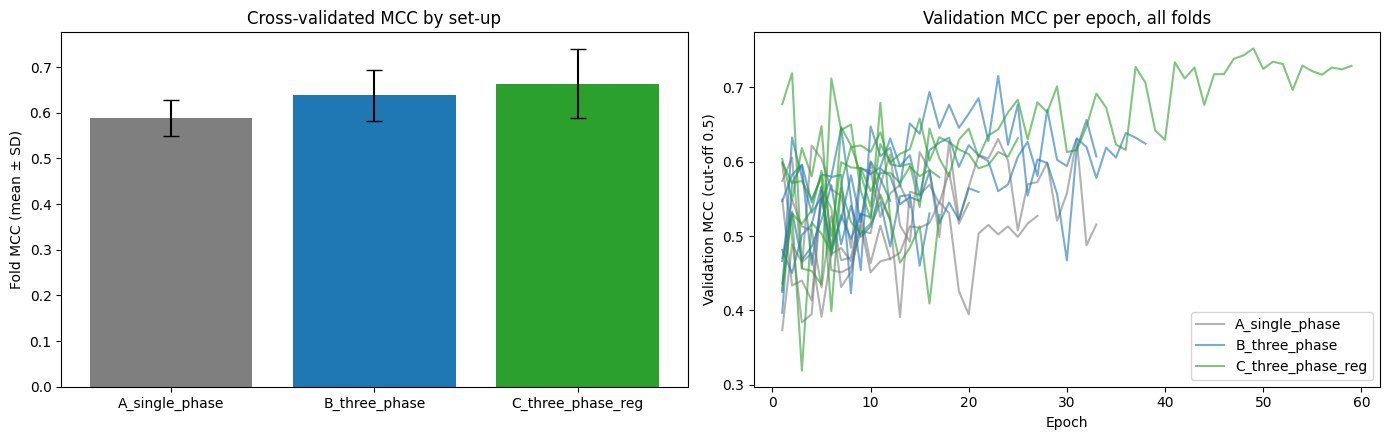

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
means = [np.mean(results[n]['fold_mccs']) for n in RUN_CONFIGS]
sds = [np.std(results[n]['fold_mccs']) for n in RUN_CONFIGS]
axes[0].bar(RUN_CONFIGS, means, yerr=sds, capsize=6, color=['tab:gray', 'tab:blue', 'tab:green'][:len(RUN_CONFIGS)])
axes[0].set_ylabel('Fold MCC (mean ± SD)'); axes[0].set_title('Cross-validated MCC by set-up')

colors = {'A_single_phase': 'tab:gray', 'B_three_phase': 'tab:blue', 'C_three_phase_reg': 'tab:green'}
for n in RUN_CONFIGS:
    for k, hist in enumerate(results[n]['histories']):
        axes[1].plot(range(1, len(hist) + 1), hist, color=colors[n], alpha=0.6, label=n if k == 0 else None)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation MCC (cut-off 0.5)')
axes[1].set_title('Validation MCC per epoch, all folds'); axes[1].legend()
plt.tight_layout(); plt.show()

## 10. Save the results

Saves the fold-by-fold MCCs, cut-offs and best epochs for every set-up, plus each fold's normalisation statistics. The trained models are already saved in `models/`. Commit the notebook (**Save & Run All**) to keep everything.

In [10]:
record = {n: {'threshold': results[n]['threshold'], 'fold_mccs': [float(m) for m in results[n]['fold_mccs']],
              'best_epochs': results[n]['best_epochs'], 'minutes': results[n]['minutes']} for n in RUN_CONFIGS}
with open(f'{OUT_DIR}/cv_results.json', 'w') as f:
    json.dump(record, f, indent=2)
np.savez(f'{OUT_DIR}/fold_norm_stats.npz',
         **{f'{n}_fold{k + 1}_{s}': results[n]['fold_stats'][k][j]
            for n in RUN_CONFIGS for k in range(N_FOLDS) for j, s in enumerate(['mean', 'std'])})
print(json.dumps(record, indent=2))

{
  "A_single_phase": {
    "threshold": 0.5100000000000001,
    "fold_mccs": [
      0.6347765045429856,
      0.6034608681849508,
      0.6222760974367489,
      0.5339372258255737,
      0.5477734582340306
    ],
    "best_epochs": [
      4,
      10,
      23,
      2,
      17
    ],
    "minutes": 0.8341431101163228
  },
  "B_three_phase": {
    "threshold": 0.4700000000000001,
    "fold_mccs": [
      0.6562791393180324,
      0.6700165719161892,
      0.7153677778726973,
      0.5806704429664913,
      0.5669902859631427
    ],
    "best_epochs": [
      2,
      28,
      23,
      11,
      6
    ],
    "minutes": 0.9091369867324829
  },
  "C_three_phase_reg": {
    "threshold": 0.6700000000000002,
    "fold_mccs": [
      0.6676958921592103,
      0.7433212661905934,
      0.7507965981863088,
      0.5760272243007256,
      0.5819441952554678
    ],
    "best_epochs": [
      15,
      49,
      2,
      7,
      7
    ],
    "minutes": 1.0384441097577413
  }
}


## 11. Final test evaluation (switched off for now)

The test set has already been used once, in Test 1. It should be used **once more, at the very end**, on the final chosen model, otherwise it stops being an honest measure.

When you are ready, set `RUN_FINAL_TEST = True` and choose `FINAL_CONFIG`. The five fold models of that set-up then each predict the test set, their probabilities are averaged (an **ensemble**), and the cut-off chosen from the out-of-fold predictions is applied.

In [11]:
RUN_FINAL_TEST = False
FINAL_CONFIG = 'C_three_phase_reg'

if RUN_FINAL_TEST:
    cfg, r = CONFIGS[FINAL_CONFIG], results[FINAL_CONFIG]
    X_in = X3 if cfg['three_phase'] else X
    probs = []
    for k in range(N_FOLDS):
        mean, std = r['fold_stats'][k]
        model = build_model(cfg).to(device)
        model.load_state_dict(torch.load(f'{OUT_DIR}/models/{FINAL_CONFIG}_fold{k + 1}.pt', map_location=device))
        loader = DataLoader(PDDataset((X_in[test_idx] - mean) / std, y[test_idx]), batch_size=256)
        probs.append(predict(model, loader))
    test_pred = np.mean(probs, axis=0) > r['threshold']
    t = y[test_idx]
    tn, fp, fn, tp = confusion_matrix(t, test_pred).ravel()
    print(f'Test MCC: {matthews_corrcoef(t, test_pred):.3f} | accuracy {accuracy_score(t, test_pred):.1%}')
    print(f'PD detected: {tp} of {tp + fn} | False alarms: {fp} of {fp + tn}')
    ConfusionMatrixDisplay.from_predictions(t, test_pred, display_labels=['No PD', 'PD'], cmap='Blues')
    plt.title(f'Test set confusion matrix ({FINAL_CONFIG}, 5-model ensemble)'); plt.show()
else:
    print('Final test evaluation is switched off. Compare set-ups using the cross-validation results above.')

Final test evaluation is switched off. Compare set-ups using the cross-validation results above.
